In [1]:
# Distance Matrix: 0=Warehouse, 1-4=Customers
dist_matrix = [
    [0, 10, 15, 20, 25],
    [10, 0, 35, 25, 30],
    [15, 35, 0, 30, 20],
    [20, 25, 30, 0, 15],
    [25, 30, 20, 15, 0]
]

# Parcel Metadata: Value, Weight (kg)
parcels = {
    1: {"val": 50, "w": 10},
    2: {"val": 100, "w": 20},
    3: {"val": 30, "w": 5},
    4: {"val": 80, "w": 15}
}
vehicle_capacity = 40  # Maximum weight constraint

In [2]:
# Task 3

def get_route_cost(route, matrix):
    if len(route) < 2:
        return 0
    return matrix[route[0]][route[1]] + get_route_cost(route[1:], matrix)

In [3]:
# Task 4

def select_parcels(data, max_w):
    # Greedy sorting by profit density
    sorted_p = sorted(data.items(), key=lambda x: x[1]['val']/x[1]['w'], reverse=True)
    selected = []
    current_w = 0
    for pid, info in sorted_p:
        if current_w + info['w'] <= max_w:
            selected.append(pid)
            current_w += info['w']
    return selected

In [4]:
# Task 6 

import itertools

def solve_tsp(matrix):
    customers = list(range(1, len(matrix)))
    min_dist = float('inf')
    best_route = None

    for p in itertools.permutations(customers):
        current_route = (0,) + p + (0,) # Start and End at Warehouse
        d = 0
        for i in range(len(current_route) - 1):
            d += matrix[current_route[i]][current_route[i+1]]
            
        if d < min_dist:
            min_dist = d
            best_route = current_route
    return best_route, min_dist

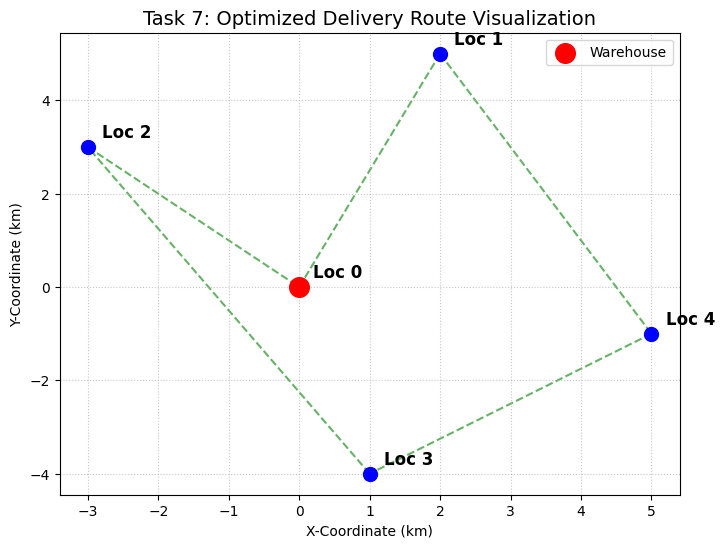

In [5]:
# Task 7

import matplotlib.pyplot as plt

def generate_delivery_graph():
    # 1. Define Coordinates for the nodes
    # Warehouse at (0,0), Customers at various points
    coords = {
        0: (0, 0),      # Warehouse
        1: (2, 5),      # Customer 1
        2: (-3, 3),     # Customer 2
        3: (1, -4),     # Customer 3
        4: (5, -1)      # Customer 4
    }

    # 2. The Optimal Route (Result from Task 6)
    # Sequence: Warehouse -> Cust 1 -> Cust 4 -> Cust 3 -> Cust 2 -> Warehouse
    route = [0, 1, 4, 3, 2, 0]

    plt.figure(figsize=(8, 6))
    
    # 3. Plot the connections (Edges)
    for i in range(len(route) - 1):
        start_node = route[i]
        end_node = route[i+1]
        x_values = [coords[start_node][0], coords[end_node][0]]
        y_values = [coords[start_node][1], coords[end_node][1]]
        plt.plot(x_values, y_values, 'g--', zorder=1, alpha=0.6) # Green dashed line
        
    for node, (x, y) in coords.items():
        if node == 0:
            plt.scatter(x, y, c='red', s=200, label='Warehouse', zorder=2)
        else:
            plt.scatter(x, y, c='blue', s=100, zorder=2)
        plt.text(x + 0.2, y + 0.2, f"Loc {node}", fontsize=12, fontweight='bold')

    plt.title("Task 7: Optimized Delivery Route Visualization", fontsize=14)
    plt.xlabel("X-Coordinate (km)")
    plt.ylabel("Y-Coordinate (km)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    
    plt.show()

generate_delivery_graph()